Dado el análisis de rendimiento de BioBERT, haremos los siguientes aumentos de datos:
- Para el Estadio T1 (textos cortos de 0-128 tokens): sustituciones por sinónimos (usando WordNet)
- Para el Estadio T4 (textos de 128 a 512 tokens): Back Translation + sustitución por sinónimos

In [4]:
import pandas as pd
import nlpaug.augmenter.word as naw
from tqdm import tqdm

In [5]:
df = pd.read_csv('../Data/interim/tcga_simple_train_preprocessed_3.csv')

# Para T1
aug_syn = naw.SynonymAug(aug_src='wordnet', lang='eng')

# Para T4
aug_bt = naw.BackTranslationAug(
    from_model_name='facebook/wmt19-en-de',
    to_model_name='facebook/wmt19-de-en',
    device="cuda"
)

def contar_tokens(texto):
    return len(str(texto).split())

datos_sinteticos = []

# ==========================================
# PROCESAMIENTO T1 (WordNet - CPU)
# ==========================================
mask_t1 = (df['t'] == 'T1') & (df['text'].apply(contar_tokens) <= 128)
df_t1 = df[mask_t1]

if not df_t1.empty:
    print(f"\nProcesando {len(df_t1)} registros de T1...")
    
    # Aplicamos tqdm al bucle de T1 para ver el progreso fila a fila
    for index, row in tqdm(df_t1.iterrows(), total=len(df_t1), desc="Aumentando T1 (Sinónimos)"):
        texto_original = str(row['text'])
        res = aug_syn.augment(texto_original)
        texto_aumentado = res[0] if isinstance(res, list) else res
        
        datos_sinteticos.append({
            'patient_id': f"{row['patient_id']}_aug",
            'text': texto_aumentado,
            't': row['t']
        })

# ==========================================
# PROCESAMIENTO T4 (Back Translation - GPU)
# ==========================================
df_t4 = df[(df['t'] == 'T4')]

if not df_t4.empty:
    print(f"\nProcesando {len(df_t4)} registros originales de T4...")
    textos_t4 = df_t4['text'].astype(str).tolist()
    ids_t4 = df_t4['patient_id'].tolist()
    
    batch_size = 4
    num_variaciones = 2
    
    # Calculamos el total exacto de textos sintéticos a generar para la barra de progreso
    total_a_generar = len(textos_t4) * num_variaciones
    
    # Usamos tqdm de forma manual para que cuente exactamente los textos nuevos
    with tqdm(total=total_a_generar, desc="Generando variaciones T4") as pbar:
        
        for i in range(0, len(textos_t4), batch_size):
            batch_textos = textos_t4[i : i + batch_size]
            batch_ids = ids_t4[i : i + batch_size]
            
            # 1. Back Translation UNA SOLA VEZ en GPU (El cuello de botella)
            textos_traducidos = aug_bt.augment(batch_textos)
            
            # 2. Generamos las 5 variaciones usando Sinónimos (Rapidísimo en CPU)
            for num_var in range(num_variaciones):
                textos_finales = aug_syn.augment(textos_traducidos)
                
                # Guardamos los resultados
                for j, texto_aug in enumerate(textos_finales):
                    datos_sinteticos.append({
                        'patient_id': f"{batch_ids[j]}_aug_v{num_var + 1}",
                        'text': texto_aug,
                        't': 'T4'
                    })
                
                # Avanzamos la barra de progreso por el número exacto de textos que acabamos de añadir
                pbar.update(len(batch_textos))

print(f"\nGenerados {len(datos_sinteticos)} nuevos registros sintéticos.")


Procesando 277 registros de T1...


Aumentando T1 (Sinónimos): 100%|██████████| 277/277 [00:01<00:00, 194.40it/s]



Procesando 521 registros originales de T4...


Generando variaciones T4: 100%|██████████| 1042/1042 [54:28<00:00,  3.14s/it]


Generados 1319 nuevos registros sintéticos.


In [6]:
df_sinteticos = pd.DataFrame(datos_sinteticos)
df_final = pd.concat([df, df_sinteticos], ignore_index=True)
df_final.to_csv('../Data/processed/tcga_simple_train_preprocessed_3_augmented.csv', index=False)

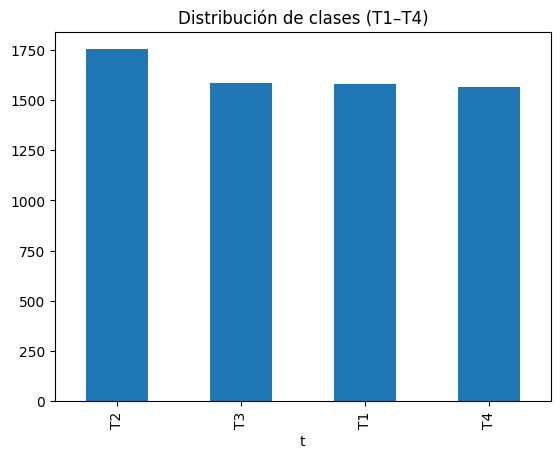

In [10]:
import matplotlib.pyplot as plt

df_final['t'].value_counts().plot(kind='bar')
plt.title("Distribución de clases (T1–T4)")
plt.show()

In [ ]:
from nltk.tokenize import word_tokenize

df['text_length'] = df['text'].apply(lambda x: len(word_tokenize(str(x))))
df['text_length'].hist(bins=50)
plt.title("Longitud de los textos")
plt.show()